# Занятие 1. Реальный датасет из интернета с текстовыми данными: психологический портрет по Big Five

## Зачем этот ноутбук

В прошлом ноутбуке мы анализировали в основном числовые данные.  
Теперь мы делаем следующий шаг: работаем с **текстовым датасетом из интернета**, где у каждого автора есть:

- текст эссе;
- 5 психологических параметров модели **Big Five**:
  - `ext` — экстраверсия;
  - `neu` — нейротизм;
  - `agr` — доброжелательность;
  - `con` — добросовестность;
  - `opn` — открытость опыту.

## Цель занятия

Показать студентам, что для дипломного проекта можно и нужно искать **реальные тематические датасеты**:
- по психологии,
- HR,
- маркетингу,
- медицине,
- финансам,
- образованию,
- производству.

И уже на их основе:
1. загружать данные из интернета;
2. изучать структуру набора данных;
3. делать первичный анализ;
4. строить графики;
5. формулировать выводы.

## Что важно понять

Здесь данные не только числовые.  
Главная колонка датасета — это **текст** (`text`), а психологические характеристики выступают как признаки/метки, по которым можно составлять **психологический портрет**.


## Практическая ячейка 1. Импорт библиотек и загрузка текстового датасета по URL

### Что делает эта ячейка
- подключает библиотеки `pandas` и `matplotlib`;
- задаёт ссылку на CSV-файл в интернете;
- загружает датасет в `DataFrame`;
- показывает первые строки таблицы.

### Краткий алгоритм
1. Импортировать библиотеки.
2. Указать URL датасета.
3. Прочитать CSV через `pd.read_csv()`.
4. Показать первые строки и размер таблицы.

### Какие библиотеки используются
- `pandas` — основная библиотека для табличного анализа данных;
- `matplotlib.pyplot` — библиотека для построения графиков;
- `IPython.display.display` — более удобный вывод таблиц в ноутбуке.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from IPython.display import display

# Публичный датасет с текстами эссе и метками Big Five
dataset_url = "https://raw.githubusercontent.com/SenticNet/personality-detection/master/essays.csv"

# Загружаем данные из интернета с устойчивой обработкой кодировки
try:
    df = pd.read_csv(dataset_url, encoding='cp1252')
except UnicodeDecodeError:
    df = pd.read_csv(dataset_url, encoding='latin1')

# Нормализуем названия столбцов и приводим их к каноническим именам
original_columns = df.columns.tolist()
rename_map = {}
for col in df.columns:
    clean = re.sub(r'[^a-z0-9]+', '', str(col).replace('﻿', '').strip().lower())

    if clean in {'text', 'essay', 'content', 'body'}:
        rename_map[col] = 'text'
    elif clean in {'authid', 'authorid', 'id'}:
        rename_map[col] = 'authid'
    elif clean in {'ext', 'cext'}:
        rename_map[col] = 'ext'
    elif clean in {'neu', 'cneu'}:
        rename_map[col] = 'neu'
    elif clean in {'agr', 'cagr'}:
        rename_map[col] = 'agr'
    elif clean in {'con', 'ccon'}:
        rename_map[col] = 'con'
    elif clean in {'opn', 'copn'}:
        rename_map[col] = 'opn'
    else:
        rename_map[col] = clean

df = df.rename(columns=rename_map)

required_columns = ['text', 'ext', 'neu', 'agr', 'con', 'opn']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(
        f'Не удалось найти обязательные столбцы: {missing_columns}. '        f'Исходные столбцы: {original_columns}. После нормализации: {df.columns.tolist()}'
    )

print('Датасет успешно загружен.')
print('Размер таблицы:', df.shape)
print('Исходные названия столбцов:', original_columns)
print('Нормализованные названия столбцов:', df.columns.tolist())
display(df.head(3))


Датасет успешно загружен.
Размер таблицы: (2467, 7)
Исходные названия столбцов: ['#AUTHID', 'TEXT', 'cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN']
Нормализованные названия столбцов: ['authid', 'text', 'ext', 'neu', 'agr', 'con', 'opn']


,authid,text,ext,neu,agr,con,opn
0,1997_504851.txt,"Well, right now I just woke up from a mid-day ...",n,y,y,n,y
1,1997_605191.txt,"Well, here we go with the stream of consciousn...",n,n,y,n,n
2,1997_687252.txt,An open keyboard and buttons to push. The thin...,n,y,n,y,y


## Практическая ячейка 2. Первичный обзор текстовых данных

### Что делает эта ячейка
- показывает названия столбцов;
- выводит типы данных;
- считает пропуски;
- показывает пример текста одного автора;
- поясняет, что такое 5 параметров Big Five.

### Краткий алгоритм
1. Посмотреть колонки и типы данных.
2. Проверить пропуски.
3. Вывести один пример текста.
4. Сопоставить короткие коды признаков с человеческими названиями.

### Какие функции используются
- `df.columns.tolist()` — получить список столбцов;
- `df.dtypes` — посмотреть типы данных;
- `df.isna().sum()` — посчитать пропуски;
- `iloc[]` — взять строку по номеру.


In [2]:
trait_names = {
    "ext": "Экстраверсия",
    "neu": "Нейротизм",
    "agr": "Доброжелательность",
    "con": "Добросовестность",
    "opn": "Открытость опыту"
}

print("Названия столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество пропусков:")
print(df.isna().sum())

print("\nСправочник параметров Big Five:")
for short_name, full_name in trait_names.items():
    print(f"{short_name} -> {full_name}")

if 'text' not in df.columns:
    raise ValueError(f"Столбец с текстом не найден. Доступные столбцы: {df.columns.tolist()}")

sample_text = str(df.iloc[0]['text'])
print("\nПример текста первого автора:")
print(sample_text[:600] + "...")


Названия столбцов:
['authid', 'text', 'ext', 'neu', 'agr', 'con', 'opn']

Типы данных:
authid    object
text      object
ext       object
neu       object
agr       object
con       object
opn       object
dtype: object

Количество пропусков:
authid    0
text      0
ext       0
neu       0
agr       0
con       0
opn       0
dtype: int64

Справочник параметров Big Five:
ext -> Экстраверсия
neu -> Нейротизм
agr -> Доброжелательность
con -> Добросовестность
opn -> Открытость опыту

Пример текста первого автора:
Well, right now I just woke up from a mid-day nap. It's sort of weird, but ever since I moved to Texas, I have had problems concentrating on things. I remember starting my homework in  10th grade as soon as the clock struck 4 and not stopping until it was done. Of course it was easier, but I still did it. But when I moved here, the homework got a little more challenging and there was a lot more busy work, and so I decided not to spend hours doing it, and just getting by. But the t

## Практическая ячейка 3. Подготовка данных и создание текстового психологического портрета

### Что делает эта ячейка
- создаёт признаки длины текста;
- переводит бинарные метки `0/1` в понятные текстовые категории;
- формирует психологический портрет одного автора по 5 параметрам.

### Краткий алгоритм
1. Посчитать длину текста в символах.
2. Посчитать количество слов.
3. Перевести `0/1` в текст: `Низкий` / `Высокий`.
4. Для одного автора собрать словарь с 5 параметрами личности.

### Какие функции используются
- `.str.len()` — длина строки;
- `.str.split().str.len()` — количество слов;
- `.map()` — замена кодов на текстовые значения;
- `dict` — удобное хранение портрета человека как набора характеристик.


In [3]:
# Признаки текста
df['text'] = df['text'].astype(str)
df['text_length_chars'] = df['text'].str.len()
df['text_length_words'] = df['text'].str.split().str.len()
df['text_length_sentences'] = df['text'].str.count(r'[.!?]+')

# Если в тексте не найдено ни одного знака конца предложения, считаем это как минимум одним предложением
df['text_length_sentences'] = df['text_length_sentences'].replace(0, 1)

# Приведём бинарные значения к числам 0/1, если они записаны как y/n, yes/no, true/false
binary_map = {'y': 1, 'n': 0, 'yes': 1, 'no': 0, 'true': 1, 'false': 0}
for trait in trait_names:
    if df[trait].dtype == 'object':
        df[trait] = df[trait].astype(str).str.strip().str.lower().map(binary_map).fillna(df[trait])
    df[trait] = pd.to_numeric(df[trait], errors='coerce')

# Перевод бинарных значений в текстовые категории
label_map = {0: 'Низкий', 1: 'Высокий'}
for trait in trait_names:
    df[f'{trait}_label'] = df[trait].map(label_map)

# Психологический портрет первого автора
person_0 = df.iloc[0]
portrait_0 = {
    trait_names['ext']: person_0['ext_label'],
    trait_names['neu']: person_0['neu_label'],
    trait_names['agr']: person_0['agr_label'],
    trait_names['con']: person_0['con_label'],
    trait_names['opn']: person_0['opn_label'],
}

print('Психологический портрет первого автора:')
for trait, value in portrait_0.items():
    print(f'- {trait}: {value}')

print('\nДополнительные признаки текста первого автора:')
print('Символов:', person_0['text_length_chars'])
print('Слов:', person_0['text_length_words'])
print('Предложений:', person_0['text_length_sentences'])


Психологический портрет первого автора:
- Экстраверсия: Низкий
- Нейротизм: Высокий
- Доброжелательность: Высокий
- Добросовестность: Низкий
- Открытость опыту: Высокий

Дополнительные признаки текста первого автора:
Символов: 3249
Слов: 660
Предложений: 37


## Практическая ячейка 4. Анализ 5 психологических параметров

### Что делает эта ячейка
- считает долю авторов с высоким уровнем по каждому из 5 параметров;
- считает среднюю длину текста по каждому параметру;
- помогает увидеть, какие черты встречаются чаще.

### Краткий алгоритм
1. Для каждого параметра посчитать долю единиц.
2. Перевести долю в проценты.
3. Для каждого параметра отдельно сравнить среднюю длину текста у групп `Низкий` и `Высокий`.

### Какие функции используются
- `.mean()` — среднее значение;
- `.mul(100)` — перевод доли в проценты;
- `.groupby()` — группировка по признаку;
- `.agg()` — агрегирование данных.


In [4]:
# Доля авторов с высоким значением по каждому параметру
trait_share_high = (
    df[list(trait_names.keys())]
    .mean()
    .mul(100)
    .rename(index=trait_names)
    .sort_values(ascending=False)
)

print("Доля авторов с высоким значением по каждому параметру, %:")
display(trait_share_high.to_frame(name="high_share_percent"))

# Сравнение средней длины текста по каждому параметру
length_by_trait = []

for trait in trait_names:
    group_stats = (
        df.groupby(f"{trait}_label")["text_length_words"]
        .mean()
        .round(2)
        .to_dict()
    )

    length_by_trait.append({
        "trait": trait_names[trait],
        "avg_words_low": group_stats.get("Низкий"),
        "avg_words_high": group_stats.get("Высокий")
    })

length_by_trait_df = pd.DataFrame(length_by_trait)
print("\nСредняя длина текста (в словах) у групп Низкий / Высокий:")
display(length_by_trait_df)


Доля авторов с высоким значением по каждому параметру, %:


,high_share_percent
Доброжелательность,53.100932
Экстраверсия,51.722740
Открытость опыту,51.520065
Добросовестность,50.790434
Нейротизм,49.979732



Средняя длина текста (в словах) у групп Низкий / Высокий:


,trait,avg_words_low,avg_words_high
0,Экстраверсия,652.15,652.12
1,Нейротизм,640.40,663.88
2,Доброжелательность,654.54,650.01
3,Добросовестность,646.03,658.05
4,Открытость опыту,642.27,661.41


## Практическая ячейка 5. Визуализация результатов

### Что делает эта ячейка
- строит столбчатую диаграмму по 5 психологическим параметрам;
- визуально показывает, какие черты чаще имеют высокий уровень;
- строит второй график по средней длине текста.

### Краткий алгоритм
1. Построить бар-чарт долей по 5 параметрам.
2. Подписать оси и заголовок.
3. Построить второй график со средней длиной текста.
4. Сравнить группы визуально.

### Какие функции используются
- `plt.figure()` — создать график;
- `plt.bar()` — столбчатая диаграмма;
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()` — подписи;
- `plt.grid()` — сетка;
- `plt.show()` — показать график.


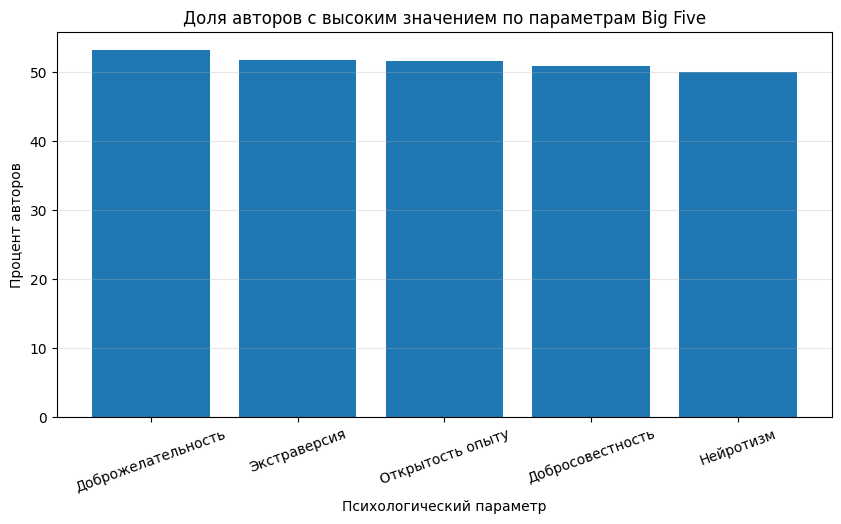

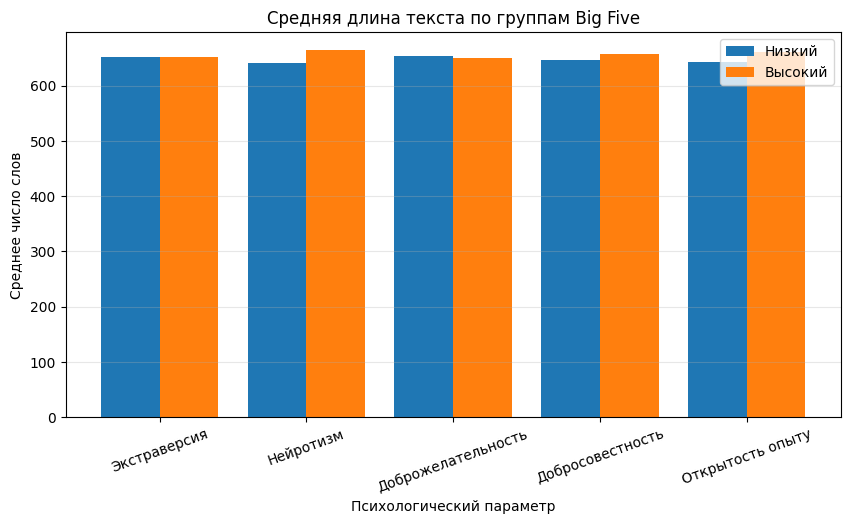

In [5]:
# График 1. Доля высокого значения по Big Five
plt.figure(figsize=(10, 5))
plt.bar(trait_share_high.index, trait_share_high.values)
plt.title("Доля авторов с высоким значением по параметрам Big Five")
plt.xlabel("Психологический параметр")
plt.ylabel("Процент авторов")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

# График 2. Средняя длина текста у групп Низкий / Высокий
plot_df = length_by_trait_df.set_index("trait")

plt.figure(figsize=(10, 5))
x = range(len(plot_df))
plt.bar([i - 0.2 for i in x], plot_df["avg_words_low"], width=0.4, label="Низкий")
plt.bar([i + 0.2 for i in x], plot_df["avg_words_high"], width=0.4, label="Высокий")
plt.xticks(list(x), plot_df.index, rotation=20)
plt.title("Средняя длина текста по группам Big Five")
plt.xlabel("Психологический параметр")
plt.ylabel("Среднее число слов")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


## Практическая ячейка 6. Выводы и мост к дипломному проекту

### Что делает эта ячейка
- формулирует понятные выводы по анализу;
- показывает, как из текстового датасета извлекать аналитические наблюдения;
- связывает это с дипломным проектом.

### Краткий алгоритм
1. Найти параметр, который чаще всего имеет высокий уровень.
2. Сравнить длину текстов между группами.
3. Сформулировать выводы обычным языком.
4. Перенести этот подход на тему диплома.

### Идея для диплома
Ваш диплом может использовать:
- отзывы клиентов,
- обращения пользователей,
- комментарии,
- анкеты,
- медицинские описания,
- HR-резюме,
- текстовые ответы респондентов.

Важно не просто скачать датасет, а показать:
- что означают его колонки;
- как вы подготовили данные;
- какие закономерности нашли;
- какие выводы сделали.


In [6]:
dominant_trait = trait_share_high.idxmax()
dominant_value = trait_share_high.max()

# Сравним, по какому параметру разница в длине текста между "Высокий" и "Низкий" максимальна
length_by_trait_df["abs_diff"] = (length_by_trait_df["avg_words_high"] - length_by_trait_df["avg_words_low"]).abs()
max_diff_row = length_by_trait_df.sort_values("abs_diff", ascending=False).iloc[0]

assert "text" in df.columns
assert all(col in df.columns for col in ["ext", "neu", "agr", "con", "opn"])
assert "text_length_words" in df.columns
assert len(trait_share_high) == 5

print("Вывод 1:")
print(f"Чаще всего высокий уровень в выборке встречается по параметру '{dominant_trait}' — примерно {dominant_value:.2f}% авторов.")

print("\nВывод 2:")
print(
    f"Наибольшая разница в средней длине текста наблюдается по параметру "
    f"'{max_diff_row['trait']}'."
)

print("\nВывод 3:")
print(
    "Даже если основной столбец — это текст, мы можем превратить его в аналитические признаки: "
    "длину текста, число слов, число предложений, а затем сравнивать группы между собой."
)

print("\nМост к дипломному проекту:")
print(
    "Для диплома ищите датасет именно по вашей теме. Если данные текстовые, "
    "их тоже можно анализировать: считать признаки, группировать, визуализировать и делать выводы."
)


Вывод 1:
Чаще всего высокий уровень в выборке встречается по параметру 'Доброжелательность' — примерно 53.10% авторов.

Вывод 2:
Наибольшая разница в средней длине текста наблюдается по параметру 'Нейротизм'.

Вывод 3:
Даже если основной столбец — это текст, мы можем превратить его в аналитические признаки: длину текста, число слов, число предложений, а затем сравнивать группы между собой.

Мост к дипломному проекту:
Для диплома ищите датасет именно по вашей теме. Если данные текстовые, их тоже можно анализировать: считать признаки, группировать, визуализировать и делать выводы.


## Что студент должен вынести из этого занятия

После выполнения ноутбука вы должны понимать:

- реальные датасеты бывают не только числовыми, но и **текстовыми**;
- текст тоже можно анализировать как данные;
- 5 психологических параметров можно использовать как основу для **психологического портрета**;
- хороший анализ — это не только загрузка файла, но и понятные выводы;
- для дипломного проекта нужно искать **датасет по теме диплома**, а не только повторять учебные примеры.

## Что можно улучшить на следующем шаге

Дальше на основе этого же датасета можно сделать:
- `TODO`-версию для студентов;
- ноутбук с элементами ИИ:
  - классификация одного из параметров Big Five,
  - кластеризация текстов,
  - поиск похожих психологических профилей.
